In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
import os

print(os.listdir("/content"))

['.config', 'casting_data.zip', 'sample_data']


In [10]:
import zipfile

zip_path = "/content/casting_data.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

In [11]:
print(os.listdir("/content/casting_data/casting_data/train"))
print(os.listdir("/content/casting_data/casting_data/test"))

['def_front', 'ok_front']
['def_front', 'ok_front']


In [12]:
train_directory = "/content/casting_data/casting_data/train"
test_directory = "/content/casting_data/casting_data/test"

In [13]:
train_directory

'/content/casting_data/casting_data/train'

In [14]:
image_size = (224, 224)
batch_size = 32

In [15]:
class_names = ["ok_front", "def_front"]

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


In [16]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32, 1)
Pixel minimum: 0.0
Pixel maximum: 254.14487


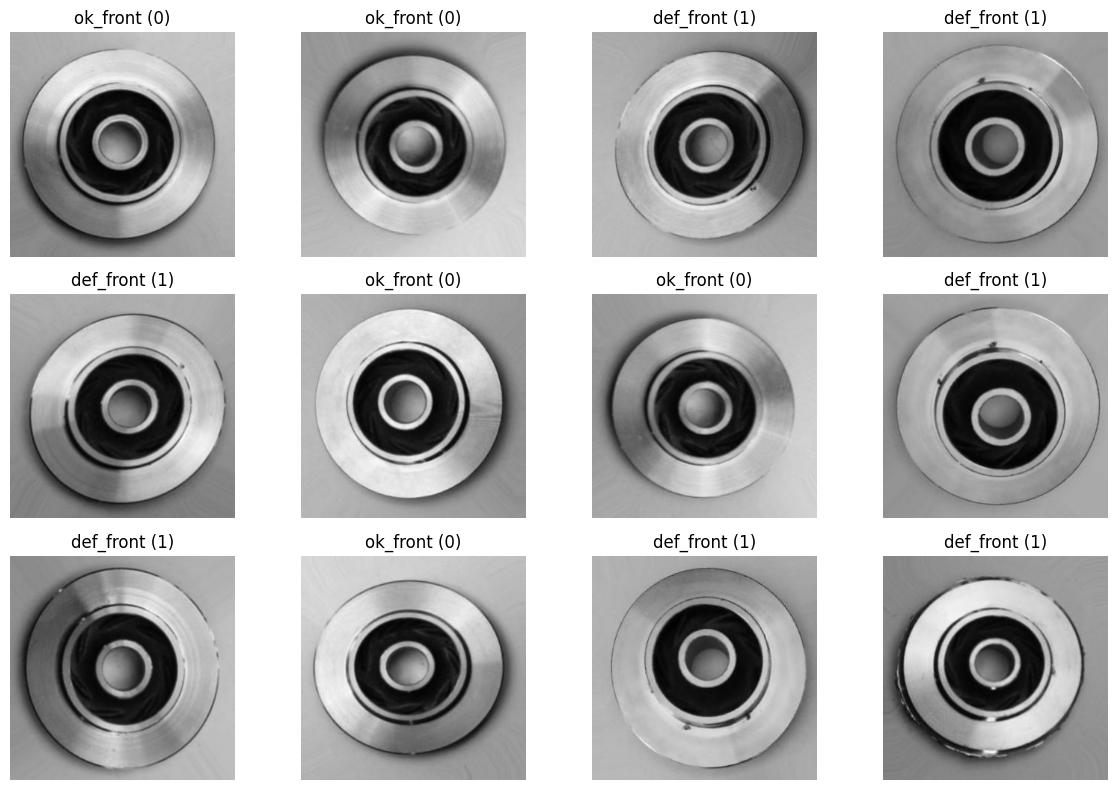

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(12):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])

        plt.title(
            f"{class_names[label]} ({label})"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [20]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [22]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [23]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.5583 - loss: 0.6888 - precision: 0.5606 - recall: 0.9819 - val_accuracy: 0.5897 - val_loss: 0.6842 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.5608 - loss: 0.6864 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6797 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.5608 - loss: 0.6849 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6744 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.5636 - loss: 0.6781 - precision: 0.5624 - recall: 0.9993 - val_accuracy: 0.5897 - val_loss: 0.6653 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - 

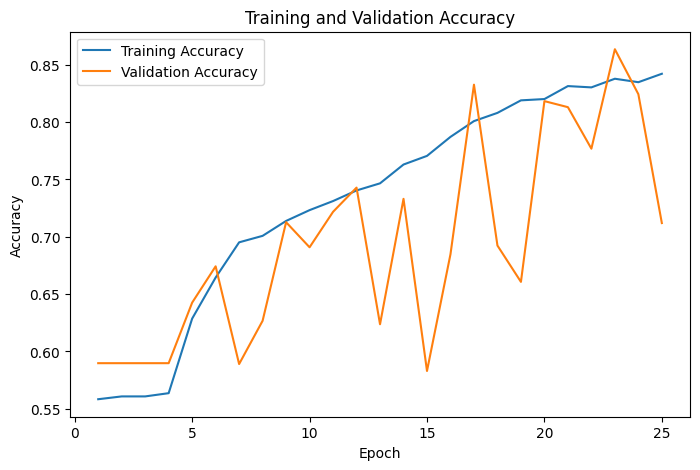

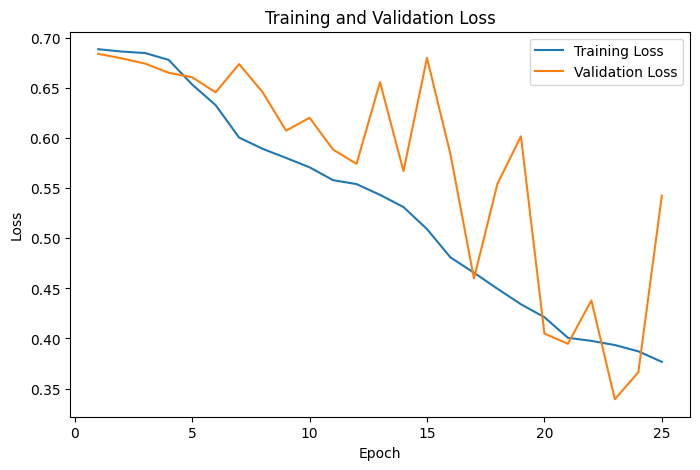

In [25]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, training_accuracy, label="Training Accuracy")
plt.plot(epochs, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, training_loss, label="Training Loss")
plt.plot(epochs, validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [26]:
test_results = model.evaluate(test_dataset)

print("Test results:", test_results)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8601 - loss: 0.3394 - precision: 0.8966 - recall: 0.8808
Test results: [0.33937257528305054, 0.8601398468017578, 0.8966292142868042, 0.8807947039604187]


In [27]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.5
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step


In [28]:
predicted_labels

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [29]:
actual_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [30]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Non-defective", "Defective"]
    )
)

               precision    recall  f1-score   support

Non-defective       0.80      0.82      0.81       262
    Defective       0.90      0.88      0.89       453

     accuracy                           0.86       715
    macro avg       0.85      0.85      0.85       715
 weighted avg       0.86      0.86      0.86       715



In [31]:
matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)

print(matrix)

[[216  46]
 [ 54 399]]


In [34]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.4
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [35]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Non-defective", "Defective"]
    )
)

               precision    recall  f1-score   support

Non-defective       0.92      0.79      0.85       262
    Defective       0.89      0.96      0.92       453

     accuracy                           0.90       715
    macro avg       0.91      0.88      0.89       715
 weighted avg       0.90      0.90      0.90       715



In [37]:
matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)
print(matrix)

[[207  55]
 [ 17 436]]


In [40]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.6
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Non-defective", "Defective"]
    )
)

matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)
print(matrix)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
               precision    recall  f1-score   support

Non-defective       0.73      0.83      0.78       262
    Defective       0.89      0.83      0.86       453

     accuracy                           0.83       715
    macro avg       0.81      0.83      0.82       715
 weighted avg       0.84      0.83      0.83       715

[[218  44]
 [ 79 374]]


In [41]:
prediction_probabilities = model.predict(test_dataset)

predicted_labels = (
    prediction_probabilities.flatten() >= 0.3
).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Non-defective", "Defective"]
    )
)

matrix = confusion_matrix(
    actual_labels,
    predicted_labels
)
print(matrix)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
               precision    recall  f1-score   support

Non-defective       0.96      0.63      0.76       262
    Defective       0.82      0.99      0.90       453

     accuracy                           0.86       715
    macro avg       0.89      0.81      0.83       715
 weighted avg       0.87      0.86      0.85       715

[[165  97]
 [  6 447]]


In [42]:

def predict_product(image_path, model, threshold=0.50):


    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )


    image_array = tf.keras.utils.img_to_array(image)


    image_array = tf.expand_dims(
        image_array,
        axis=0
    )


    defect_probability = float(
        model.predict(
            image_array,
            verbose=0
        )[0][0]
    )

    # Classification
    if defect_probability >= threshold:

        predicted_class = "Defective"

        recommended_action = (
            "Send for manual inspection"
        )

    else:

        predicted_class = "Non-defective"

        recommended_action = (
            "Product may proceed"
        )

    print("Image:", image_path)
    print("Prediction:", predicted_class)
    print(
        f"Defect probability: "
        f"{defect_probability:.2%}"
    )
    print(
        f"Decision threshold: "
        f"{threshold:.2f}"
    )
    print(
        "Recommended action:",
        recommended_action
    )

    return predicted_class, defect_probability

In [46]:
predict_product(
    "/content/smaple_images/image1.jpeg",
    model,
    threshold=0.50
)

Image: /content/smaple_images/image1.jpeg
Prediction: Non-defective
Defect probability: 2.61%
Decision threshold: 0.50
Recommended action: Product may proceed


('Non-defective', 0.02609698660671711)

In [47]:
predict_product(
    "/content/smaple_images/image2.jpeg",
    model,
    threshold=0.50
)

Image: /content/smaple_images/image2.jpeg
Prediction: Defective
Defect probability: 77.24%
Decision threshold: 0.50
Recommended action: Send for manual inspection


('Defective', 0.7724283933639526)